In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path
from lifelines import KaplanMeierFitter
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

# Note: This script retains the original thesis development paths and is not intended
# to be executed in the public repository without access to the private data environment.

MAIN_DIR = Path("/Users/chanyoungwoo/Thesis/ATE_CATE")
CATE_H1_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_train.csv"
CATE_H2_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_train.csv"
CATE_H3_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_train.csv"
CATE_H1_TEST_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_test.csv"
CATE_H2_TEST_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_test.csv"
CATE_H3_TEST_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_test.csv"
VI_H1_FP   = MAIN_DIR / "Model_New_horizon_1/csf_variable_importance.csv"
VI_H2_FP   = MAIN_DIR / "Model_New_horizon_2/csf_variable_importance.csv"
VI_H3_FP   = MAIN_DIR / "Model_New_horizon_3/csf_variable_importance.csv"
PARQUET_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_csf_data_train.parquet"
PARQUET_TEST_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_test_ver10.parquet"

h1 = pd.read_csv(CATE_H1_FP).rename(columns={"tau":"tau1"})
h2 = pd.read_csv(CATE_H2_FP).rename(columns={"tau":"tau2"})
h3 = pd.read_csv(CATE_H3_FP).rename(columns={"tau":"tau3"})
df = h1.merge(h2, on="PX_ID").merge(h3, on="PX_ID")

h1_test = pd.read_csv(CATE_H1_TEST_FP).rename(columns={"tau":"tau1"})
h2_test = pd.read_csv(CATE_H2_TEST_FP).rename(columns={"tau":"tau2"})
h3_test = pd.read_csv(CATE_H3_TEST_FP).rename(columns={"tau":"tau3"})
df_test = h1_test.merge(h2_test, on="PX_ID").merge(h3_test, on="PX_ID")

vi_h1 = pd.read_csv(VI_H1_FP)
vi_h2 = pd.read_csv(VI_H2_FP)
vi_h3 = pd.read_csv(VI_H3_FP)

In [2]:
taus = df_test[["tau1","tau2","tau3"]].values
scaler = StandardScaler().fit(taus)
Z = scaler.transform(taus)           
Z_df = pd.DataFrame(Z, columns=["z1","z2","z3"], index=df_test["PX_ID"])

Dimensionality Reduction for Visualization

- take each patients 3-dimensional CATE (tau1, tau2, tau3) and run a PCA down to 2 dimensions
- plot a Scatter Plot 

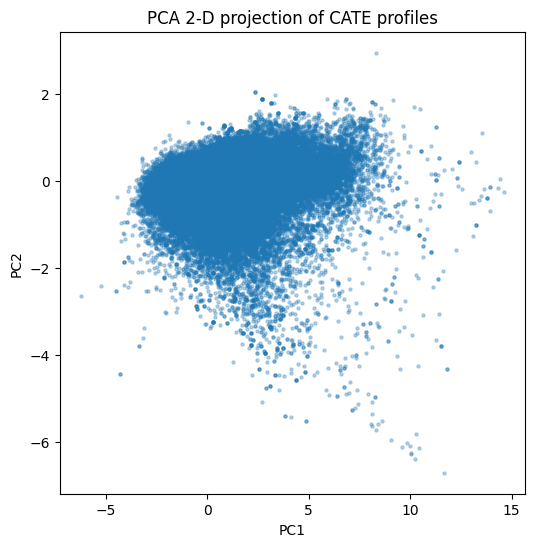

In [3]:
pca = PCA(n_components=2).fit(Z)
coords = pca.transform(Z)
plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=5, alpha=0.3)
plt.title("PCA 2-D projection of CATE profiles")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

K-Means Clustering & Model Selection

- run a K-Means on the full 3-dimensional CATE vectors for K = 2,3,4
- compute the average silhouette score ->measures how well each point lies within its own cluster vs. the next one close
- searching for K where clusters are both tight and well seperated

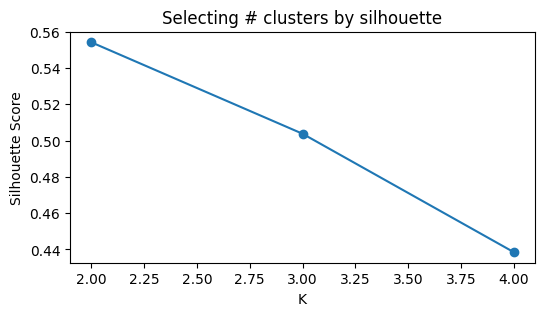

In [4]:
scores = []
Ks = range(2,5)
for K in Ks:
    km = KMeans(n_clusters=K, random_state=42).fit(Z)
    scores.append(silhouette_score(Z, km.labels_))
    
plt.figure(figsize=(6,3))
plt.plot(Ks, scores, marker="o")
plt.xlabel("K"); plt.ylabel("Silhouette Score")
plt.title("Selecting # clusters by silhouette")
plt.show()

In [6]:
import numpy as np

In [7]:
best_K = Ks[np.argmax(scores)]
km = KMeans(n_clusters=best_K, random_state=42).fit(Z)
df_test["cluster"] = km.labels_

print("Chosen K =", best_K)

Chosen K = 2


Characterize & Visualize Clusters

- for each of the two clusters fit, compute the mean (tau1, tau2, tau3) centroid and plot
- cluster centroids: gives the treatment effect curve in each group

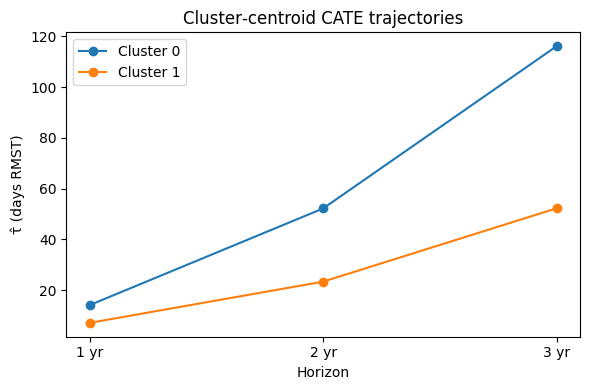

In [8]:
centroids = scaler.inverse_transform(km.cluster_centers_)
traj = pd.DataFrame(centroids, columns=["τ̂ 1yr","τ̂ 2yr","τ̂ 3yr"])
traj.index.name = "cluster"
traj.reset_index(inplace=True)

plt.figure(figsize=(6,4))
for _, row in traj.iterrows():
    plt.plot([1,2,3], row[["τ̂ 1yr","τ̂ 2yr","τ̂ 3yr"]],
             marker="o", label=f"Cluster {int(row['cluster'])}")
plt.xticks([1,2,3], ["1 yr","2 yr","3 yr"])
plt.xlabel("Horizon"); plt.ylabel("τ̂ (days RMST)")
plt.title("Cluster‐centroid CATE trajectories")
plt.legend(); plt.tight_layout()
plt.show()

Visualize clusters on PCA space

- color each PCA point by its cluster label

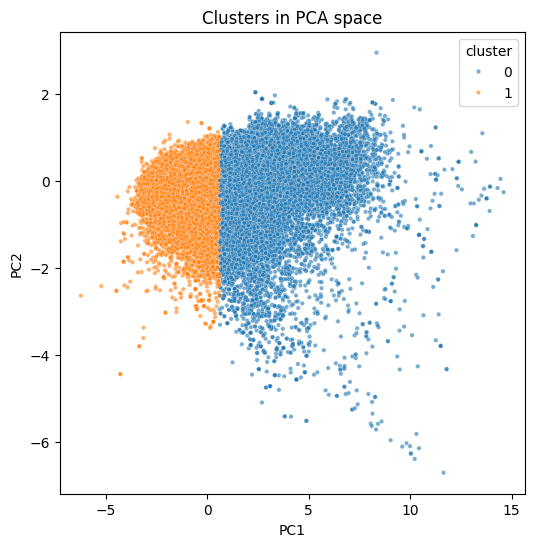

In [9]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1],
                hue=df_test["cluster"], palette="tab10", s=10, alpha=0.6)
plt.title("Clusters in PCA space"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="cluster"); plt.show()

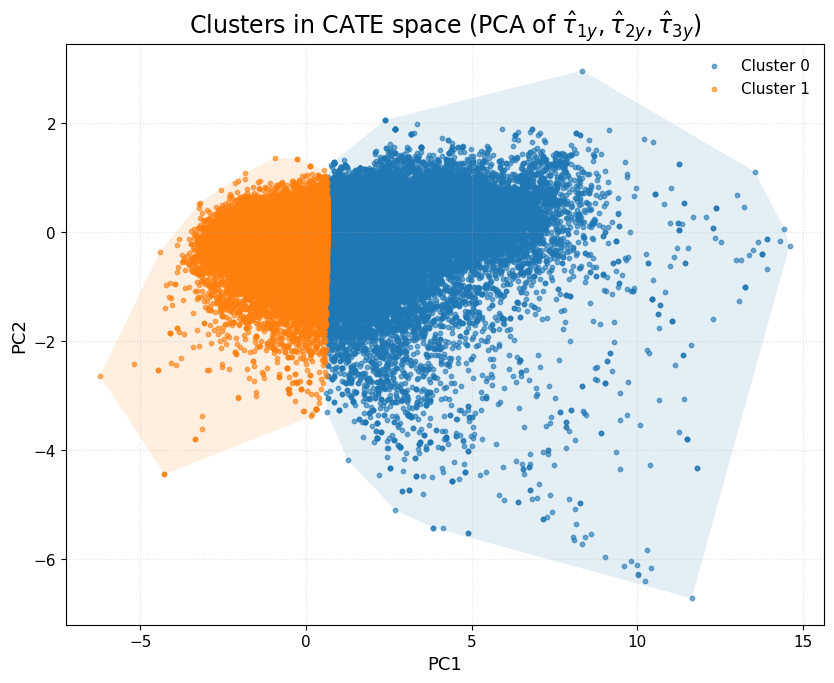

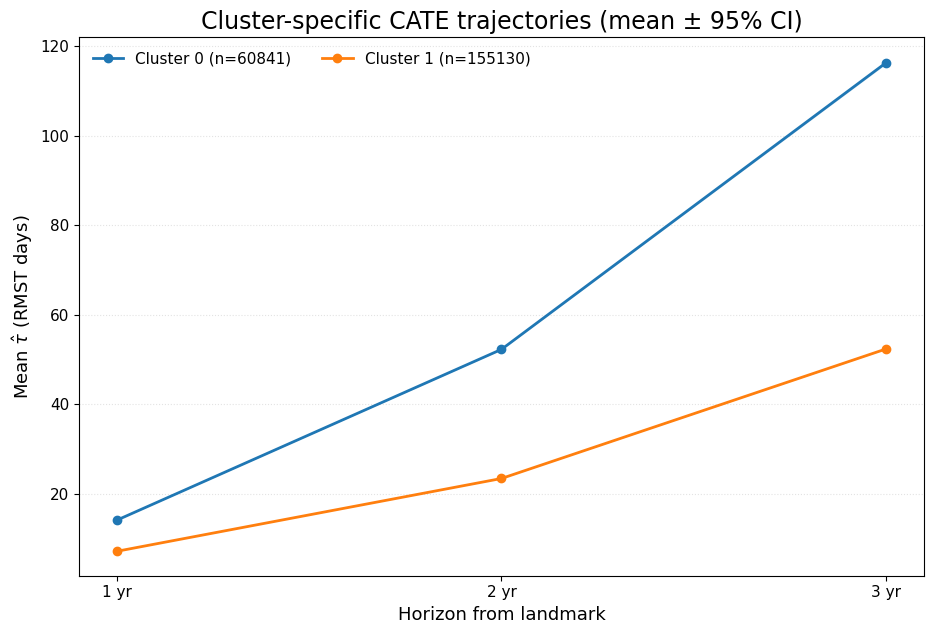

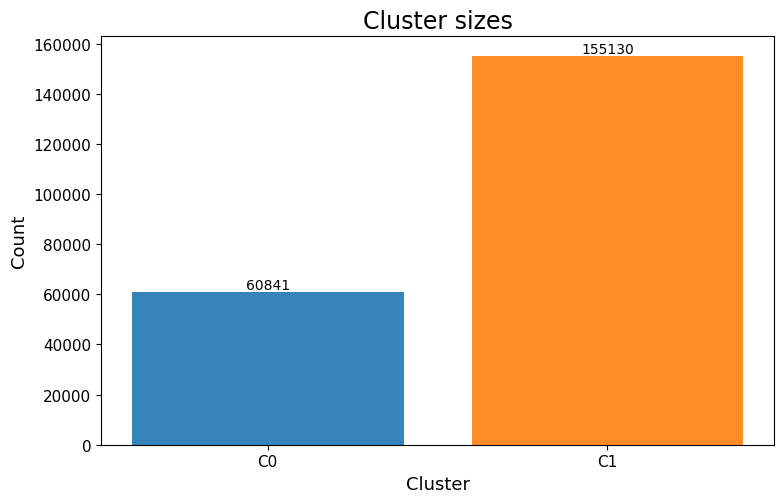

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

tau_cols = ["tau1", "tau2", "tau3"]
assert set(tau_cols).issubset(df_test.columns), "tau columns not found in df_test"
assert "cluster" in df_test.columns, "cluster labels not found in df_test"

def cluster_colors(labels):
    uniq = np.sort(np.unique(labels))
    cmap = plt.get_cmap("tab10")
    return {c: cmap(int(i) % 10) for i, c in enumerate(uniq)}

CLRS = cluster_colors(df_test["cluster"].values)

X = df_test[tau_cols].values.astype(float)
coords = PCA(n_components=2, random_state=42).fit_transform(StandardScaler().fit_transform(X))
df_embed = pd.DataFrame(coords, columns=["PC1","PC2"])
df_embed["cluster"] = df_test["cluster"].values

fig, ax = plt.subplots(figsize=(8.5, 7))
for c, sub in df_embed.groupby("cluster"):
    ax.scatter(sub["PC1"], sub["PC2"], s=10, alpha=0.6, color=CLRS[c], label=f"Cluster {int(c)}")
    if len(sub) >= 3:
        try:
            hull = ConvexHull(sub[["PC1","PC2"]].values)
            hull_pts = sub.iloc[hull.vertices][["PC1","PC2"]].values
            ax.fill(hull_pts[:,0], hull_pts[:,1], color=CLRS[c], alpha=0.12, linewidth=0)
        except Exception:
            pass

ax.set_title("Clusters in CATE space (PCA of $\\hat{\\tau}_{1y},\\hat{\\tau}_{2y},\\hat{\\tau}_{3y}$)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(loc="upper right", frameon=False)
ax.grid(axis="both", linestyle=":", alpha=0.35)
plt.tight_layout()
plt.savefig(MAIN_DIR / "fig_cluster_pca.pdf", bbox_inches="tight")
plt.savefig(MAIN_DIR / "fig_cluster_pca.png", dpi=600, bbox_inches="tight")
plt.show()

rows = []
for c, sub in df_test.groupby("cluster"):
    n = len(sub)
    means = sub[tau_cols].mean()
    ses   = sub[tau_cols].std(ddof=1) / np.sqrt(n)
    rows.append({
        "cluster": c,
        "n": n,
        "m1": means["tau1"], "m2": means["tau2"], "m3": means["tau3"],
        "lo1": means["tau1"] - 1.96*ses["tau1"], "hi1": means["tau1"] + 1.96*ses["tau1"],
        "lo2": means["tau2"] - 1.96*ses["tau2"], "hi2": means["tau2"] + 1.96*ses["tau2"],
        "lo3": means["tau3"] - 1.96*ses["tau3"], "hi3": means["tau3"] + 1.96*ses["tau3"],
    })
traj = pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)

x = np.array([1,2,3])
labels_x = ["1 yr","2 yr","3 yr"]

fig, ax = plt.subplots(figsize=(9.5, 6.5))
for _, r in traj.iterrows():
    y  = np.array([r["m1"], r["m2"], r["m3"]], dtype=float)
    lo = np.array([r["lo1"], r["lo2"], r["lo3"]], dtype=float)
    hi = np.array([r["hi1"], r["hi2"], r["hi3"]], dtype=float)
    ax.plot(x, y, marker="o", linewidth=2, color=CLRS[r["cluster"]], label=f"Cluster {int(r['cluster'])} (n={int(r['n'])})")
    ax.fill_between(x, lo, hi, color=CLRS[r["cluster"]], alpha=0.18, linewidth=0)

ax.set_xticks(x); ax.set_xticklabels(labels_x)
ax.set_xlabel("Horizon from landmark"); ax.set_ylabel(r"Mean $\hat{\tau}$ (RMST days)")
ax.set_title("Cluster-specific CATE trajectories (mean ± 95% CI)")
ax.legend(loc="best", frameon=False, ncol=2)
ax.grid(axis="y", linestyle=":", alpha=0.35)
plt.tight_layout()
plt.savefig(MAIN_DIR / "fig_cluster_trajectories.pdf", bbox_inches="tight")
plt.savefig(MAIN_DIR / "fig_cluster_trajectories.png", dpi=600, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5.2))
sizes = df_test["cluster"].value_counts().sort_index()
ax.bar(range(len(sizes)), sizes.values, color=[CLRS[c] for c in sizes.index], alpha=0.9)
ax.set_xticks(range(len(sizes))); ax.set_xticklabels([f"C{int(c)}" for c in sizes.index])
ax.set_xlabel("Cluster"); ax.set_ylabel("Count")
ax.set_title("Cluster sizes")
for i, v in enumerate(sizes.values):
    ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(MAIN_DIR / "fig_cluster_sizes.pdf", bbox_inches="tight")
plt.savefig(MAIN_DIR / "fig_cluster_sizes.png", dpi=600, bbox_inches="tight")
plt.show()

if "Delta" in df_test.columns:
    ev = df_test.groupby("cluster")["Delta"].mean().sort_index()
    fig, ax = plt.subplots(figsize=(8, 5.2))
    ax.bar(range(len(ev)), (100*ev.values), color=[CLRS[c] for c in ev.index], alpha=0.9)
    ax.set_xticks(range(len(ev))); ax.set_xticklabels([f"C{int(c)}" for c in ev.index])
    ax.set_xlabel("Cluster"); ax.set_ylabel("Event rate (%)")
    ax.set_title("Post-landmark mortality by cluster")
    for i, v in enumerate(100*ev.values):
        ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.savefig(MAIN_DIR / "fig_cluster_eventrate.pdf", bbox_inches="tight")
    plt.savefig(MAIN_DIR / "fig_cluster_eventrate.png", dpi=600, bbox_inches="tight")
    plt.show()


In [47]:
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [51]:
df_test_cov = pd.read_parquet(PARQUET_TEST_FP)
df_test_full = df_test.merge(df_test_cov, on="PX_ID", how="left")
assert "cluster" in df_test_full.columns, "cluster labels missing in df_test_full"
uniq_clusters = np.sort(df_test_full["cluster"].dropna().unique())
assert len(uniq_clusters) == 2, f"Expected 2 clusters; got {uniq_clusters}"

print(df_test_full.shape)
print(df_test_full.head())

(215971, 84)
       PX_ID       tau1       tau2        tau3  cluster  CAN_AGE_AT_LISTING  \
0  1082720.0   6.117982  15.455920   42.114415        1            0.319444   
1 -1853507.0   7.903269  29.593881   75.580875        1            0.541667   
2   804175.0  10.850882  37.574400   74.521379        1            0.722222   
3 -1716651.0  12.732004  53.479476  128.157423        0            0.611111   
4 -1740666.0  17.809532  63.545408  148.144837        0            0.416667   

    CAN_BMI  CAN_DRUG_TREAT_COPD  CAN_MALIG  CAN_MAX_PCT_SCLER_LT10  ...  \
0  0.354839                 -1.0        0.0                    0.20  ...   
1  0.290323                  0.0        0.0                    1.00  ...   
2  0.241935                  0.0        0.0                    0.55  ...   
3  0.209677                  0.0        0.0                    1.00  ...   
4  0.241935                  0.0        0.0                    1.00  ...   

   CAN_DGN_Kidney HIV nephropathy  \
0                 

In [52]:
exclude_cols = {
    "PX_ID","Y","Delta","T","T_365","ps",
    "ipc_weight_365","ipc_weight_730","ipc_weight_1095",
    "WL_EVENT","WL_TIME",
    "tau1","tau2","tau3"
}

cand_cols = [c for c in df_test_full.columns if c not in exclude_cols and c != "cluster"]

print("Candidate columns:", cand_cols)

Candidate columns: ['CAN_AGE_AT_LISTING', 'CAN_BMI', 'CAN_DRUG_TREAT_COPD', 'CAN_MALIG', 'CAN_MAX_PCT_SCLER_LT10', 'CAN_MIN_FINAL_CREAT', 'CAN_MIN_PEAK_CREAT', 'CAN_ON_DIAL', 'CAN_PERIPH_VASC', 'CAN_TOT_ALBUMIN', 'MAX_CPRA', 'CAN_RACE_Asian', 'CAN_RACE_Black', 'CAN_RACE_MISSING', 'CAN_RACE_Multiracial', 'CAN_RACE_Native American', 'CAN_RACE_Pacific Islander', 'CAN_RACE_White', 'CAN_ABO_A', 'CAN_ABO_A1', 'CAN_ABO_A1B', 'CAN_ABO_A2', 'CAN_ABO_A2B', 'CAN_ABO_AB', 'CAN_ABO_B', 'CAN_ABO_O', 'CAN_ABO_Unkown', 'CAN_DIAL_Dialysis-Unknown Type Performed', 'CAN_DIAL_Hemodialysis', 'CAN_DIAL_MISSING', 'CAN_DIAL_No dialysis', 'CAN_DIAL_Peritoneal Dialysis', 'CAN_DIAL_Unknown', 'CAN_FUNCTN_STAT_Fully independent', 'CAN_FUNCTN_STAT_Independent with effort', 'CAN_FUNCTN_STAT_No Assistance', 'CAN_FUNCTN_STAT_Not applicable', 'CAN_FUNCTN_STAT_Partially dependent', 'CAN_FUNCTN_STAT_Some Assistance', 'CAN_FUNCTN_STAT_Total Assistance', 'CAN_FUNCTN_STAT_Totally dependent', 'CAN_FUNCTN_STAT_Unknown', 'CAN_

In [53]:
def is_binary_series(s: pd.Series):
    s = s.dropna()
    if s.empty: return False
    vals = set(s.unique())
    return vals.issubset({0, 1}) and len(vals) <= 2

binary_cols = []
cont_cols   = []
for c in cand_cols:
    if pd.api.types.is_numeric_dtype(df_test_full[c]):
        if is_binary_series(df_test_full[c]):
            binary_cols.append(c)
        else:
            cont_cols.append(c)

cont_cols = [c for c in cont_cols if df_test_full[c].nunique(dropna=True) > 1]
binary_cols = [c for c in binary_cols if df_test_full[c].nunique(dropna=True) == 2]

In [54]:
g0 = df_test_full["cluster"] == uniq_clusters[0]
g1 = df_test_full["cluster"] == uniq_clusters[1]

rows = []

In [55]:
for c in cont_cols:
    x0 = df_test_full.loc[g0, c].dropna().astype(float)
    x1 = df_test_full.loc[g1, c].dropna().astype(float)
    if len(x0) < 3 or len(x1) < 3: 
        continue
    m0, s0, n0 = x0.mean(), x0.std(ddof=1), x0.size
    m1, s1, n1 = x1.mean(), x1.std(ddof=1), x1.size
    sd_pooled = np.sqrt((s0**2 + s1**2) / 2.0)
    smd = (m1 - m0) / sd_pooled if sd_pooled > 0 else np.nan
    tstat, pval = stats.ttest_ind(x1, x0, equal_var=False, nan_policy="omit")
    rows.append({
        "variable": c,
        "type": "continuous",
        "n_cluster0": int(n0),
        "mean_cluster0": m0,
        "sd_cluster0": s0,
        "n_cluster1": int(n1),
        "mean_cluster1": m1,
        "sd_cluster1": s1,
        "pct_cluster0": np.nan,
        "pct_cluster1": np.nan,
        "SMD": smd,
        "test": "Welch t-test",
        "p_value": pval
    })

for c in binary_cols:
    s0 = df_test_full.loc[g0, c]
    s1 = df_test_full.loc[g1, c]
    s0v = s0.dropna().astype(int)
    s1v = s1.dropna().astype(int)
    n0, n1 = s0v.size, s1v.size
    if n0 == 0 or n1 == 0:
        continue
    p0 = s0v.mean()  
    p1 = s1v.mean()
    p_pool = (s0v.sum() + s1v.sum()) / (n0 + n1)
    denom = np.sqrt(p_pool * (1 - p_pool)) if 0 < p_pool < 1 else np.nan
    smd = (p1 - p0) / denom if denom and denom > 0 else np.nan

    table = np.array([
        [s0v.sum(), n0 - s0v.sum()],
        [s1v.sum(), n1 - s1v.sum()]
    ], dtype=float)

    chi2_ok = True
    try:
        chi2, chi_p, dof, exp = stats.chi2_contingency(table, correction=False)
        if (exp < 5).any():
            chi2_ok = False
    except Exception:
        chi2_ok = False
    if chi2_ok:
        pval = chi_p
        test_name = "Chi-square"
    else:
        try:
            _, pval = stats.fisher_exact(table)
            test_name = "Fisher exact"
        except Exception:
            pval = np.nan
            test_name = "Chi-square (failed)/Fisher (failed)"
    rows.append({
        "variable": c,
        "type": "binary",
        "n_cluster0": int(n0),
        "mean_cluster0": np.nan,
        "sd_cluster0": np.nan,
        "n_cluster1": int(n1),
        "mean_cluster1": np.nan,
        "sd_cluster1": np.nan,
        "pct_cluster0": 100.0 * p0,
        "pct_cluster1": 100.0 * p1,
        "SMD": smd,
        "test": test_name,
        "p_value": pval
    })

results = pd.DataFrame(rows)

In [56]:
mask_valid_p = results["p_value"].notna()
rej, qvals, _, _ = multipletests(results.loc[mask_valid_p, "p_value"].values, method="fdr_bh")
results.loc[mask_valid_p, "q_value"] = qvals
results.loc[~mask_valid_p, "q_value"] = np.nan

results["abs_SMD"] = results["SMD"].abs()
results_sorted = results.sort_values(["abs_SMD"], ascending=False).reset_index(drop=True)

preview_cols = [
    "variable","type",
    "n_cluster0","mean_cluster0","sd_cluster0","pct_cluster0",
    "n_cluster1","mean_cluster1","sd_cluster1","pct_cluster1",
    "SMD","p_value","q_value","test"
]
display(results_sorted[preview_cols].head(15))

,variable,type,n_cluster0,mean_cluster0,sd_cluster0,pct_cluster0,n_cluster1,mean_cluster1,sd_cluster1,pct_cluster1,SMD,p_value,q_value,test
0,CAN_DGN_Kidney Diabetic or metabolic nephropathy,binary,60841,NaN,NaN,74.214756,155130,NaN,NaN,25.609489,-0.995150,0.0,0.0,Chi-square
1,CAN_DIAB_TY_No,binary,60841,NaN,NaN,33.262109,155130,NaN,NaN,73.183137,0.822196,0.0,0.0,Chi-square
2,CAN_DIAB_TY_Unknown,binary,60841,NaN,NaN,22.198846,155130,NaN,NaN,1.989944,-0.758817,0.0,0.0,Chi-square
3,CAN_MAX_PCT_SCLER_LT10,continuous,60841,0.584326,0.360535,NaN,155130,0.373130,0.279077,NaN,-0.655096,0.0,0.0,Welch t-test
4,MAX_CPRA,continuous,60841,0.028546,0.111453,NaN,155130,0.166413,0.297624,NaN,0.613494,0.0,0.0,Welch t-test
5,CAN_MED_COND_MISSING,binary,60841,NaN,NaN,18.684768,155130,NaN,NaN,46.459099,0.570418,0.0,0.0,Chi-square
6,CAN_MED_COND_Not Hospitalized,binary,60841,NaN,NaN,80.708733,155130,NaN,NaN,53.138013,-0.565016,0.0,0.0,Chi-square
7,CAN_FUNCTN_STAT_Independent with effort,binary,60841,NaN,NaN,31.611906,155130,NaN,NaN,56.981886,0.507402,0.0,0.0,Chi-square
8,CAN_TOT_ALBUMIN,continuous,60841,0.556452,0.091488,NaN,155130,0.599823,0.093958,NaN,0.467702,0.0,0.0,Welch t-test
9,CAN_FUNCTN_STAT_No Assistance,binary,60841,NaN,NaN,37.811673,155130,NaN,NaN,18.105460,-0.463703,0.0,0.0,Chi-square


In [57]:
out_csv = MAIN_DIR / "cluster_baseline_comparison_full.csv"
results_sorted.to_csv(out_csv, index=False)
print(f"Saved full results to: {out_csv}")

Saved full results to: /Users/chanyoungwoo/Thesis/ATE_CATE/cluster_baseline_comparison_full.csv


In [61]:
top10 = results_sorted.head(15)
print("\nTop differences by SMD:")
for _, r in top10.iterrows():
    if r["type"] == "continuous":
        print(f" - {r['variable']}: mean C0={r['mean_cluster0']:.2f} vs C1={r['mean_cluster1']:.2f}, "
              f"SMD={r['SMD']:.2f}, q={r['q_value']:.3g}")
    else:
        print(f" - {r['variable']}: % C0={r['pct_cluster0']:.1f} vs C1={r['pct_cluster1']:.1f}, "
              f"SMD={r['SMD']:.2f}, q={r['q_value']:.3g}")


Top differences by SMD:
 - CAN_DGN_Kidney Diabetic or metabolic nephropathy: % C0=74.2 vs C1=25.6, SMD=-1.00, q=0
 - CAN_DIAB_TY_No: % C0=33.3 vs C1=73.2, SMD=0.82, q=0
 - CAN_DIAB_TY_Unknown: % C0=22.2 vs C1=2.0, SMD=-0.76, q=0
 - CAN_MAX_PCT_SCLER_LT10: mean C0=0.58 vs C1=0.37, SMD=-0.66, q=0
 - MAX_CPRA: mean C0=0.03 vs C1=0.17, SMD=0.61, q=0
 - CAN_MED_COND_MISSING: % C0=18.7 vs C1=46.5, SMD=0.57, q=0
 - CAN_MED_COND_Not Hospitalized: % C0=80.7 vs C1=53.1, SMD=-0.57, q=0
 - CAN_FUNCTN_STAT_Independent with effort: % C0=31.6 vs C1=57.0, SMD=0.51, q=0
 - CAN_TOT_ALBUMIN: mean C0=0.56 vs C1=0.60, SMD=0.47, q=0
 - CAN_FUNCTN_STAT_No Assistance: % C0=37.8 vs C1=18.1, SMD=-0.46, q=0
 - CAN_MALIG: mean C0=-0.19 vs C1=-0.01, SMD=0.42, q=0
 - CAN_DGN_Kidney Glomerulonephritis: % C0=3.7 vs C1=17.1, SMD=0.40, q=0
 - CAN_DGN_Kidney Hypertensive or vascular injury: % C0=9.9 vs C1=25.6, SMD=0.38, q=0
 - CAN_AGE_AT_LISTING: mean C0=0.50 vs C1=0.44, SMD=-0.37, q=0
 - CAN_RACE_White: % C0=61.5 vs 